# 5-D. RFE 제거 순서 재현 실험 (Cross-Seed Validation)
### 목적
- 05c에서 도출된 RFE 제거 순서를 시드 43, 44로 독립 분할된 데이터에서 재현하여 안정성 검증
- 데이터: fs_train + fs_validation (04_feature_engineering 기준 42 피처)을 합쳐 시드별 재분할


In [9]:
# ── Cell 1: 라이브러리 & 설정 ──────────────────────────────────────
import os, sys, warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../.."))

def check_gpu():
    try:
        lgb.train({'device': 'gpu', 'verbose': -1}, lgb.Dataset(np.zeros((1, 1)), label=[0]))
        return True
    except:
        return False

def _set_korean_font():
    for name in ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]:
        if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False
_set_korean_font()

class LocalConfig:
    TRAIN_SRC   = "../../data2/04_feature_engineering/fs_train.parquet"
    VAL_SRC     = "../../data2/04_feature_engineering/fs_validation.parquet"
    OUT_DIR     = "."
    TARGET_COL  = "failure"
    SEED        = 42
    SPLIT_SEEDS = [43, 44, 45]
    TRAIN_RATIO = 0.7
    LGBM_PARAMS = {
        "objective": "binary", "importance_type": "gain",
        "max_depth": 7, "num_leaves": 60, "n_estimators": 300,
        "learning_rate": 0.03,
        "device": "gpu" if check_gpu() else "cpu",
        "random_state": SEED, "bagging_seed": SEED,
        "feature_fraction_seed": SEED, "data_random_seed": SEED,
        "n_jobs": -1, "verbose": -1,
    }

print("✅ 설정 완료 | GPU:", check_gpu())


✅ 설정 완료 | GPU: True


In [10]:
# ── Cell 2: 디스크 레벨 평가 헬퍼 함수 (Self-Contained) ─────────────
import numpy as np
import pandas as pd
import time

def get_rolling_n_largest(probs, n, W):
    if len(probs) < n: return 0.0
    if len(probs) < W: return np.sort(probs)[-n]
    try:
        from numpy.lib.stride_tricks import sliding_window_view
        windows = sliding_window_view(probs, W)
        return np.partition(windows, -n, axis=1)[:, -n].max()
    except:
        return max(np.partition(probs[i:i+W], -n)[-n] for i in range(len(probs)-W+1))

def prepare_disk_level_data(df, y_prob, target_col="failure", serial_col="serial_number", date_col="date"):
    df = df.copy()
    df["y_prob"] = np.asarray(y_prob)
    df["base_serial"] = df[serial_col].str.replace(r'_\d+$', '', regex=True)
    df = df.sort_values(["base_serial", date_col])
    disks_data = []
    for bs, grp in df.groupby("base_serial"):
        disks_data.append({
            "base_serial": bs,
            "is_failed": int(grp[target_col].max()),
            "probs": grp["y_prob"].values,
            "dates": grp[date_col].values,
            "failures": grp[target_col].values
        })
    n_failed = sum(d["is_failed"] for d in disks_data)
    return disks_data, n_failed, len(disks_data) - n_failed

def run_disk_level_grid_search(disks_data, thresholds, min_alarms_list, n_failed, n_normal,
                               log_dir=None, window_size=0, horizon=30):
    is_failed_arr = np.array([d['is_failed'] for d in disks_data], dtype=bool)
    nth_probs = np.zeros((len(disks_data), len(min_alarms_list)))
    
    failed_days, failed_probs = [], []
    for d in disks_data:
        if d['is_failed']:
            dates = pd.Series(pd.to_datetime(d['dates']))
            failed_days.append((dates.iloc[-1] - dates).dt.days.values)
            failed_probs.append(d['probs'])

    for idx, d in enumerate(disks_data):
        p = d['probs']
        for ni, n in enumerate(min_alarms_list):
            if len(p) < n:
                nth_probs[idx, ni] = 0.0
            elif not window_size:
                nth_probs[idx, ni] = np.sort(p)[::-1][n-1]
            else:
                nth_probs[idx, ni] = get_rolling_n_largest(p, n, window_size)

    results = []
    t0 = time.perf_counter()
    total = len(min_alarms_list) * len(thresholds)
    cnt = 0
    for ni, n in enumerate(min_alarms_list):
        nth_p = nth_probs[:, ni]
        for T in thresholds:
            cnt += 1
            alarmed = (nth_p >= T)
            fps = np.sum(alarmed & ~is_failed_arr)
            tps = 0
            for dd, dp in zip(failed_days, failed_probs):
                idx_arr = np.where(dp >= T)[0]
                if len(idx_arr) >= n and dd[idx_arr[n-1]] <= horizon:
                    tps += 1
            results.append({
                'threshold': T, 'min_alarms': n,
                'recall': tps/n_failed if n_failed else 0.0,
                'far': fps/n_normal if n_normal else 0.0,
                'tps': tps, 'fps': fps
            })
            if cnt % 500 == 0 or cnt == total:
                print(f"  ... {cnt:,}/{total:,} ({100*cnt/total:.1f}%) - {time.perf_counter()-t0:.1f}s")
    return pd.DataFrame(results)

def compute_disk_prauc(disks_data, n_failed, n_normal, thresholds=None):
    from sklearn.metrics import auc
    if thresholds is None:
        thresholds = np.linspace(0.001, 0.999, 100)
    df_grid = run_disk_level_grid_search(disks_data, thresholds, [1], n_failed, n_normal)
    df_s = df_grid.sort_values("recall").copy()
    df_s["precision"] = df_s["tps"] / (df_s["tps"] + df_s["fps"] + 1e-8)
    df_s["precision"] = df_s["precision"].fillna(1.0)
    return float(auc(df_s["recall"].values, df_s["precision"].values))

print("✅ 평가 헬퍼 함수 로드 완료")


✅ 평가 헬퍼 함수 로드 완료


In [11]:
# ── Cell 3: 데이터 로드 및 시드별 분할 ────────────────────────────────
FEATURES_42 = [
    "s191_days_since_last",
    "reallocated_pending_ratio",
    "s242_28d_asfd",
    "s194_28d_mean",
    "total_seeks_diff",
    "s190_28d_std",
    "total_seeks_14d_mean",
    "smart_197_raw",
    "smart_183_raw",
    "smart_184_raw",
    "s187_damaged",
    "s241_diff",
    "s241_14d_mean",
    "s198_28d_max",
    "s242_14d_mean",
    "s187_28d_sum",
    "age_weighted_workload",
    "s187_days_since_first",
    "error_density_14d",
    "smart_241_raw",
    "workload_intensity",
    "smart_242_raw",
    "total_seeks_28d_max",
    "smart_9_raw",
    "smart_198_raw",
    "smart_187_raw",
    "write_stability_ratio",
    "total_seeks_28d_asfd",
    "s5_days_since_first",
    "s199_days_since_last",
    "multi_error_count",
    "s194_28d_dai",
    "s194_28d_std",
    "s242_28d_dai",
    "total_reads_7d_asfd",
    "total_reads_7d_max",
    "s194_14d_max",
    "s194_28d_ewma",
    "s194_14d_std",
    "s190_28d_zscore",
    "s190_28d_ewma",
    "s190_28d_mean"
]

print("📂 원본 데이터 로드 중 (04_feature_engineering)...")
meta_cols = ["serial_number", "date", LocalConfig.TARGET_COL]
load_cols = meta_cols + FEATURES_42

df_train_src = pd.read_parquet(LocalConfig.TRAIN_SRC, columns=load_cols)
df_val_src   = pd.read_parquet(LocalConfig.VAL_SRC,   columns=load_cols)

df_all = pd.concat([df_train_src, df_val_src], ignore_index=True)
df_all["date"] = pd.to_datetime(df_all["date"])
df_all = df_all.sort_values(["serial_number", "date"]).reset_index(drop=True)

print(f"합산 데이터: {len(df_all):,} rows | 고장 디스크: {df_all.groupby('serial_number')['failure'].max().sum():.0f}")
print("✅ 데이터 로드 완료")


📂 원본 데이터 로드 중 (04_feature_engineering)...
합산 데이터: 6,410,643 rows | 고장 디스크: 3531
✅ 데이터 로드 완료


In [12]:
# ── Cell 4: RFE 재현 실험 (2 Seed x 42 Step) ──────────────────────────
REMOVAL_ORDER = [
    "multi_error_count",
    "s241_14d_mean",
    "total_reads_7d_asfd",
    "s187_damaged",
    "s190_28d_zscore",
    "smart_197_raw",
    "s194_28d_ewma",
    "s190_28d_mean",
    "total_reads_7d_max",
    "s242_28d_dai",
    "write_stability_ratio",
    "error_density_14d",
    "s194_28d_std",
    "s198_28d_max",
    "s191_days_since_last",
    "s190_28d_std",
    "s194_28d_mean",
    "s194_14d_std",
    "s199_days_since_last",
    "s194_28d_dai",
    "total_seeks_28d_max",
    "s190_28d_ewma",
    "s242_14d_mean",
    "age_weighted_workload",
    "smart_242_raw",
    "reallocated_pending_ratio",
    "total_seeks_14d_mean",
    "s194_14d_max",
    "s242_28d_asfd",
    "smart_187_raw",
    "s187_days_since_first",
    "workload_intensity",
    "total_seeks_diff",
    "s241_diff",
    "smart_183_raw",
    "total_seeks_28d_asfd",
    "smart_9_raw",
    "s5_days_since_first",
    "smart_241_raw",
    "s187_28d_sum",
    "smart_184_raw"
]

def train_evaluate_disk(df_tr, y_tr, df_vl, y_vl, features):
    from sklearn.metrics import auc
    model = LGBMClassifier(**LocalConfig.LGBM_PARAMS)
    model.fit(df_tr[features], y_tr,
              eval_set=[(df_vl[features], y_vl)],
              eval_metric="average_precision",
              callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False)])
    val_prob = model.predict_proba(df_vl[features])[:, 1]
    df_eval = pd.DataFrame({
        'serial_number': df_vl['serial_number'].values,
        'date': df_vl['date'].values,
        'failure': y_vl.values
    })
    disks_data, n_failed, n_normal = prepare_disk_level_data(df_eval, val_prob)
    prauc = compute_disk_prauc(disks_data, n_failed, n_normal)
    return prauc

all_results = []

for split_seed in LocalConfig.SPLIT_SEEDS:
    sep = "=" * 60
    print(f"\n{sep}")
    print(f"🌱 SEED {split_seed} 분할 실험 시작")
    print(f"{sep}")

    # 디스크 단위 고장 여부 기준 층화 분할 (serial_number 기준)
    from sklearn.model_selection import train_test_split
    serial_stats = df_all.groupby("serial_number")["failure"].max().reset_index()
    serial_stats.columns = ["serial_number", "has_failed"]

    train_sn, val_sn = train_test_split(
        serial_stats["serial_number"],
        test_size=(1.0 - LocalConfig.TRAIN_RATIO),
        random_state=split_seed,
        stratify=serial_stats["has_failed"]
    )
    train_serials = set(train_sn)

    df_tr = df_all[df_all["serial_number"].isin(train_serials)].reset_index(drop=True)
    df_vl = df_all[~df_all["serial_number"].isin(train_serials)].reset_index(drop=True)
    y_tr  = df_tr[LocalConfig.TARGET_COL]
    y_vl  = df_vl[LocalConfig.TARGET_COL]

    print(f"Train: {len(df_tr):,} rows | Val: {len(df_vl):,} rows")
    print(f"Val 고장 디스크: {df_vl.groupby('serial_number')['failure'].max().sum():.0f}")

    # Baseline
    print(f"\n[Baseline] 전체 42 피처 학습 중...")
    baseline_prauc = train_evaluate_disk(df_tr, y_tr, df_vl, y_vl, FEATURES_42)
    print(f"-> Baseline Disk PR-AUC: {baseline_prauc:.5f}")

    step_results = [{
        "seed": split_seed,
        "num_removed": 0,
        "removed_feature": "None (Baseline)",
        "remaining_count": len(FEATURES_42),
        "prauc": baseline_prauc
    }]

    current_features = list(FEATURES_42)
    for step_i, feat_to_remove in enumerate(REMOVAL_ORDER, 1):
        if feat_to_remove not in current_features:
            print(f"  [Step {step_i}] ⚠️ '{feat_to_remove}' 없음 - 건너뜀")
            continue
        current_features.remove(feat_to_remove)
        prauc = train_evaluate_disk(df_tr, y_tr, df_vl, y_vl, current_features)
        step_results.append({
            "seed": split_seed,
            "num_removed": step_i,
            "removed_feature": feat_to_remove,
            "remaining_count": len(current_features),
            "prauc": prauc
        })
        diff = prauc - (step_results[-2]["prauc"])
        sign = "+" if diff >= 0 else ""
        print(f"  [Step {step_i:2d}] 제거: '{feat_to_remove:30s}' | PR-AUC: {prauc:.5f} ({sign}{diff:.5f}) | 잔여: {len(current_features)}개")

        # 루프 내 즉시 CSV 저장
        df_partial = pd.DataFrame(step_results)
        csv_path = os.path.join(LocalConfig.OUT_DIR, f"rfe_replay_seed{split_seed}.csv")
        df_partial.to_csv(csv_path, index=False)

    all_results.extend(step_results)
    print(f"\n✅ Seed {split_seed} 완료 -> {csv_path}")

df_all_results = pd.DataFrame(all_results)
full_csv = os.path.join(LocalConfig.OUT_DIR, "rfe_replay_all_seeds.csv")
df_all_results.to_csv(full_csv, index=False)
print(f"\n🎉 전체 완료 -> {full_csv}")



🌱 SEED 43 분할 실험 시작
Train: 4,439,478 rows | Val: 1,971,165 rows
Val 고장 디스크: 1059

[Baseline] 전체 42 피처 학습 중...
  ... 100/100 (100.0%) - 0.2s
-> Baseline Disk PR-AUC: 0.29678
  ... 100/100 (100.0%) - 0.2s
  [Step  1] 제거: 'multi_error_count             ' | PR-AUC: 0.29582 (-0.00095) | 잔여: 41개
  ... 100/100 (100.0%) - 0.2s
  [Step  2] 제거: 's241_14d_mean                 ' | PR-AUC: 0.30203 (+0.00621) | 잔여: 40개
  ... 100/100 (100.0%) - 0.2s
  [Step  3] 제거: 'total_reads_7d_asfd           ' | PR-AUC: 0.29624 (-0.00579) | 잔여: 39개
  ... 100/100 (100.0%) - 0.2s
  [Step  4] 제거: 's187_damaged                  ' | PR-AUC: 0.30128 (+0.00504) | 잔여: 38개
  ... 100/100 (100.0%) - 0.1s
  [Step  5] 제거: 's190_28d_zscore               ' | PR-AUC: 0.29733 (-0.00395) | 잔여: 37개
  ... 100/100 (100.0%) - 0.2s
  [Step  6] 제거: 'smart_197_raw                 ' | PR-AUC: 0.29733 (-0.00000) | 잔여: 36개
  ... 100/100 (100.0%) - 0.1s
  [Step  7] 제거: 's194_28d_ewma                 ' | PR-AUC: 0.30034 (+0.00301) | 잔여: 35개
 

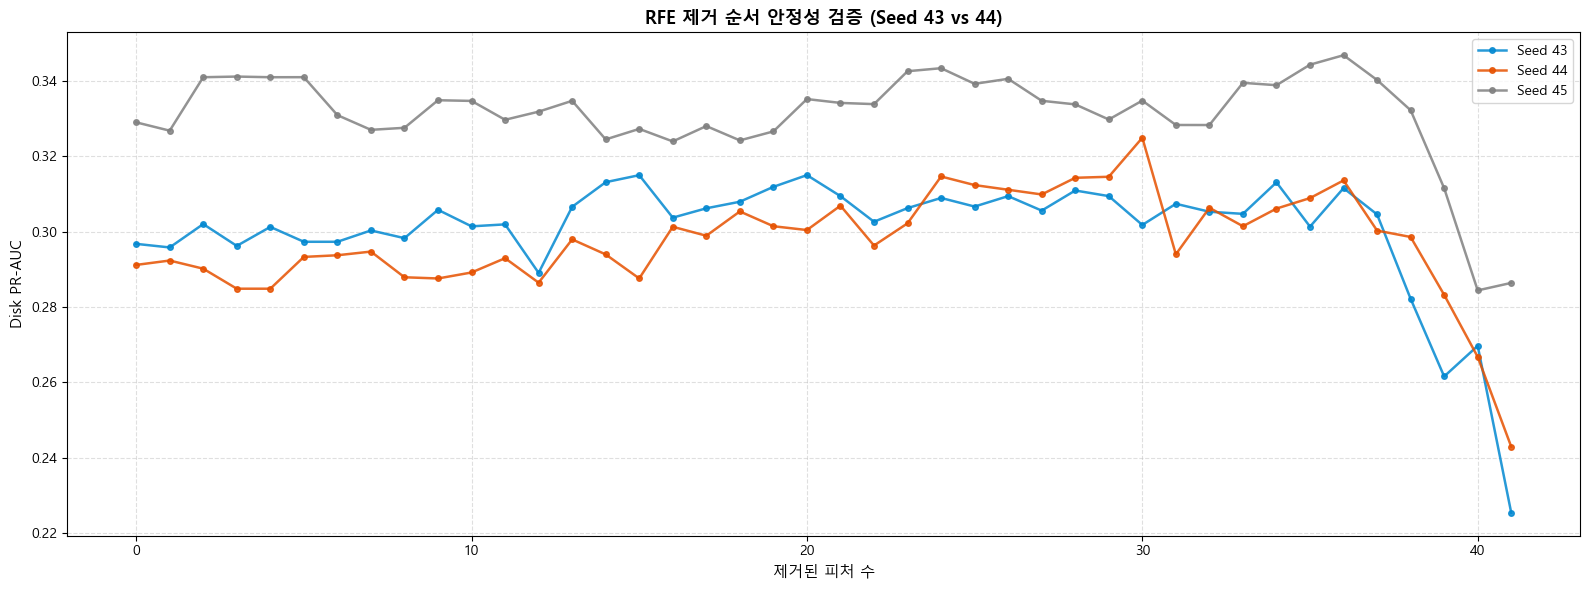

✅ 시각화 완료


In [13]:
# ── Cell 5: 결과 시각화 ──────────────────────────────────────────────
import matplotlib.pyplot as plt

df_res = pd.read_csv("rfe_replay_all_seeds.csv")

fig, ax = plt.subplots(figsize=(16, 6))
colors = {43: '#0288d1', 44: '#e65100'}
for seed, grp in df_res.groupby("seed"):
    ax.plot(grp["num_removed"], grp["prauc"],
            marker='o', markersize=4, linewidth=1.8,
            color=colors.get(seed, 'gray'),
            label=f"Seed {seed}", alpha=0.85)

ax.set_xlabel("제거된 피처 수", fontsize=11)
ax.set_ylabel("Disk PR-AUC", fontsize=11)
ax.set_title("RFE 제거 순서 안정성 검증 (Seed 43 vs 44)", fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("rfe_replay_comparison.png", dpi=150)
plt.show()
print("✅ 시각화 완료")
